# Import and setup

In [86]:
import pandas as pd
import string
import requests
import io
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt

In [87]:
#Enable this cell if using Google Colab
#from google.colab import drive
#drive.mount('/content/drive')
#base_path = '/content/drive/My Drive/MADS/SIADS 696 Milestone II/Group Project/Data/'

In [88]:
base_path = '../data/'

# Load Merged Data

Each row represents a population subgroup defined by **age group, gender, and survey cycle**. Because the survey is conducted **biennially (every two years)**, observations are available only for each survey cycle rather than annually.

In [89]:
#load cleaned data from local
merged_df = pd.read_csv(f'{base_path}merged_df.csv')
merged_df.head()

,age,gender,year,deaths,crude_rate_per_100k,population,RIDAGEYR,RIAGENDR,SEQN,BMXWT,...,DMDEDUC2_4.0,DMDEDUC2_5.0,DMDEDUC2_7.0,DMDEDUC2_9.0,DMDEDUC2_nan,SMQ020_1.0,SMQ020_2.0,SMQ020_7.0,SMQ020_9.0,SMQ020_nan
0,12.0,1,2005,417.0,19.054617,2187680.5,12.0,1,81,51.624691,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,12.0,1,2007,344.5,16.038654,2147943.0,12.0,1,37,54.877778,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,12.0,1,2009,335.0,15.841427,2114302.5,12.0,1,37,51.908108,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,12.0,1,2011,316.5,15.035152,2104934.0,12.0,1,41,55.526829,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,12.0,1,2013,312.5,14.621161,2137969.5,12.0,1,56,49.380357,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


# Unsupervised Learning

In [90]:

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt
import seaborn as sns

## Preprocess Dataset

- Remove observations with missing values.
- Standardize numerical features to ensure all variables are on a comparable scale for clustering.


In [91]:
def preprocess_unsupervised(df, feature_cols, scale=True):
    """
    Prepare a feature matrix for unsupervised learning.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataset.
    feature_cols : list[str]
        Names of the feature columns to use.
    scale : bool, default=True
        Whether to standardize the features.

    Returns
    -------
    tuple
        If ``scale`` is True:
            (X_scaled, scaler, index)
        Otherwise:
            (X, None, index)
    """
    X = df[feature_cols].copy()

    # Remove rows with missing values.
    X = X.dropna()

    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        return X_scaled, scaler, X.index

    return X.to_numpy(), None, X.index

## Correlation Analysis & Redundancy Reduction

To improve clustering performance and interpretability, highly correlated and redundant features were removed before applying K-means. Variables were reviewed within each clinical domain to retain the most informative measures while minimizing redundancy.

- **Demographics**
- **Body Measurements**
- **Blood pressure**
- **Smoking**
- **Lipids**


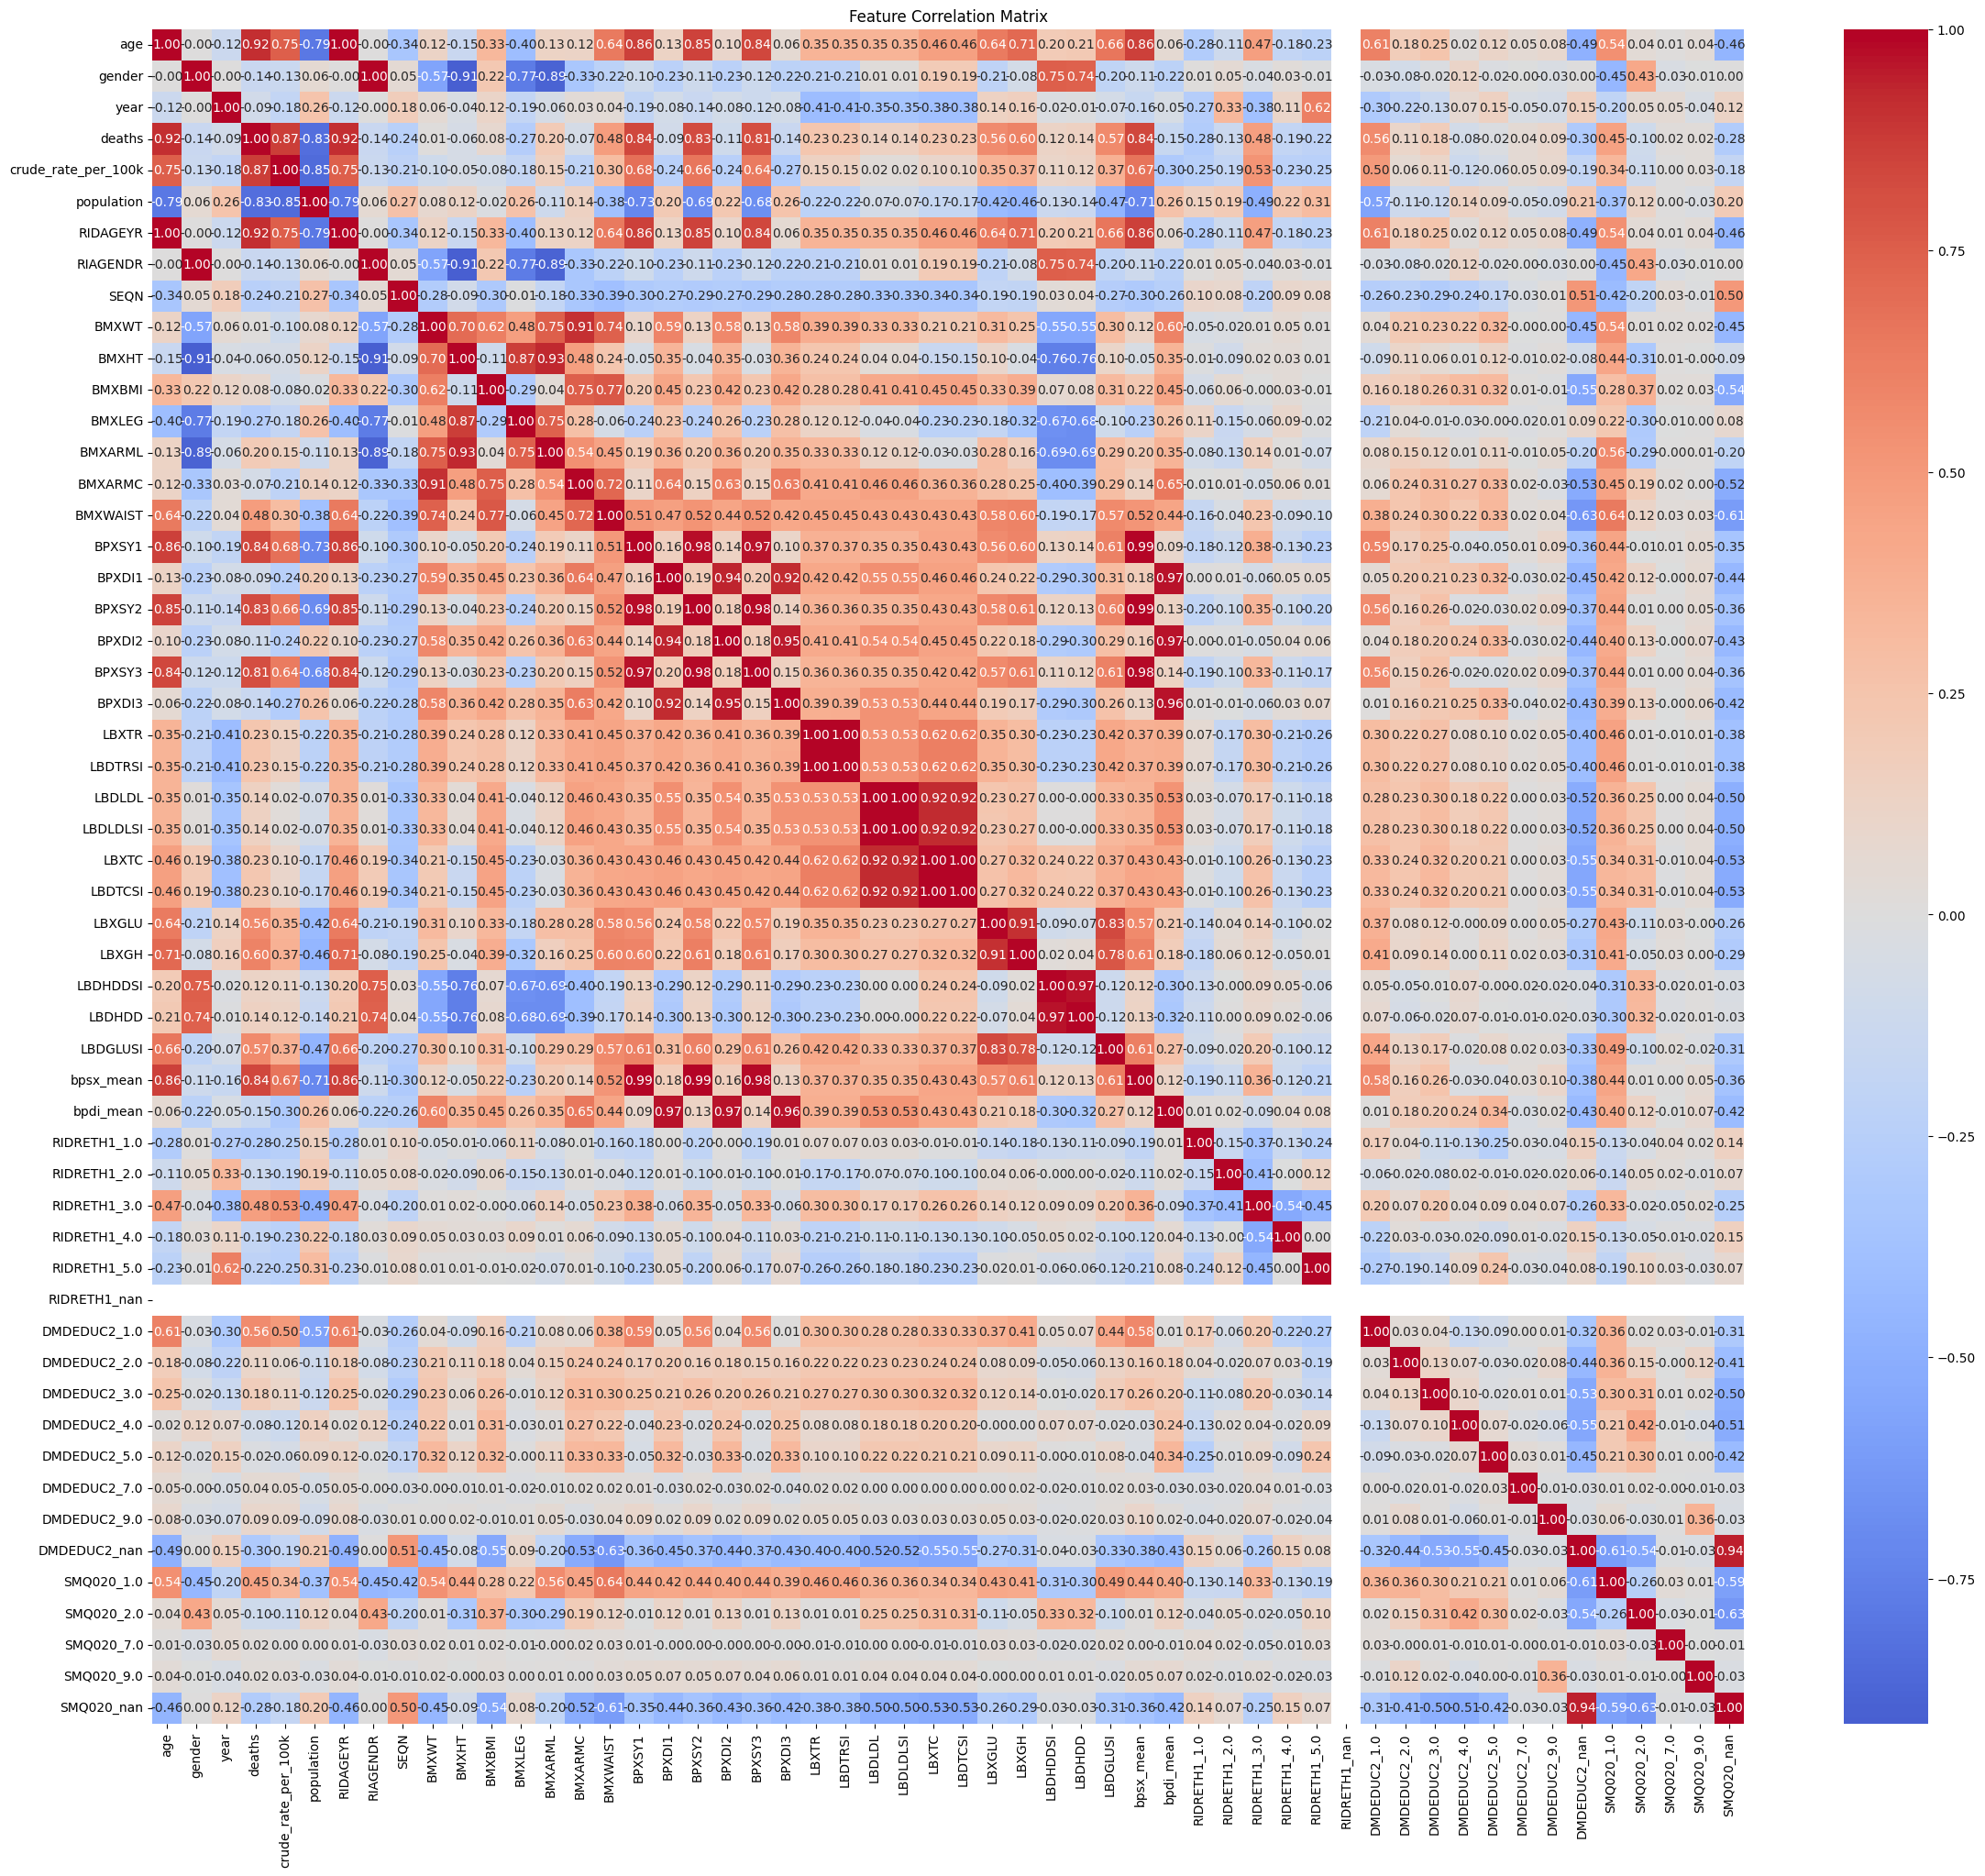

In [92]:
corr = merged_df.corr()

plt.figure(figsize=(28,24))
sns.heatmap(
    corr,
    annot=True,      # show numbers
    fmt=".2f",       # 2 decimal places
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [93]:
# ── Flag highly correlated pairs ───────────────────────────────────────────
CORR_THRESHOLD = 0.85

high_corr_pairs = []
cols = corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        corr_value = corr.iloc[i, j]

        if abs(corr_value) >= CORR_THRESHOLD:
            high_corr_pairs.append(
                {
                    "feature_1": cols[i],
                    "feature_2": cols[j],
                    "correlation": round(corr_value, 4),
                }
            )

hc_df = pd.DataFrame(high_corr_pairs)

if hc_df.empty:
    print(f"No feature pairs with |r| >= {CORR_THRESHOLD}. No redundancy detected.")
else:
    print(f"Highly correlated pairs (|r| >= {CORR_THRESHOLD}):")
    display(hc_df.sort_values("feature_1", ascending=False))


# ── Greedy removal of redundant features ───────────────────────────────────
def remove_highly_correlated(df_features, threshold=CORR_THRESHOLD):
    """
    Remove features with high pairwise correlation.

    Parameters
    ----------
    df_features : pandas.DataFrame
        Input feature matrix.
    threshold : float
        Correlation threshold above which features are considered redundant.

    Returns
    -------
    tuple
        - Reduced DataFrame
        - List of dropped columns
    """
    corr_matrix = df_features.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop = [
        col for col in upper.columns if (upper[col] >= threshold).any()
    ]

    return df_features.drop(columns=to_drop), to_drop


X_reduced, dropped_cols = remove_highly_correlated(
    merged_df, CORR_THRESHOLD
)

print(f"\nDropped {len(dropped_cols)} redundant feature(s): {dropped_cols}")
print(f"Remaining features ({len(X_reduced.columns)}): {X_reduced.columns.tolist()}")#

Highly correlated pairs (|r| >= 0.85):


,feature_1,feature_2,correlation
5,gender,RIAGENDR,1.0000
6,gender,BMXHT,-0.9136
7,gender,BMXARML,-0.8851
8,deaths,crude_rate_per_100k,0.8684
9,deaths,RIDAGEYR,0.9162
10,crude_rate_per_100k,population,-0.8508
0,age,deaths,0.9162
2,age,BPXSY1,0.8595
3,age,BPXSY2,0.8537
4,age,bpsx_mean,0.8613



Dropped 23 redundant feature(s): ['deaths', 'crude_rate_per_100k', 'population', 'RIDAGEYR', 'RIAGENDR', 'BMXHT', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BPXSY1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'LBDTRSI', 'LBDLDLSI', 'LBXTC', 'LBDTCSI', 'LBXGH', 'LBDHDD', 'bpsx_mean', 'bpdi_mean', 'SMQ020_nan']
Remaining features (31): ['age', 'gender', 'year', 'SEQN', 'BMXWT', 'BMXBMI', 'BMXWAIST', 'BPXDI1', 'LBXTR', 'LBDLDL', 'LBXGLU', 'LBDHDDSI', 'LBDGLUSI', 'RIDRETH1_1.0', 'RIDRETH1_2.0', 'RIDRETH1_3.0', 'RIDRETH1_4.0', 'RIDRETH1_5.0', 'RIDRETH1_nan', 'DMDEDUC2_1.0', 'DMDEDUC2_2.0', 'DMDEDUC2_3.0', 'DMDEDUC2_4.0', 'DMDEDUC2_5.0', 'DMDEDUC2_7.0', 'DMDEDUC2_9.0', 'DMDEDUC2_nan', 'SMQ020_1.0', 'SMQ020_2.0', 'SMQ020_7.0', 'SMQ020_9.0']


## Feature Selection

The variable *year* was excluded to prevent temporal effects from influencing cluster formation. In addition, demographic variables such as race/ethnicity and educational attainment, as well as smoking history and mortality-related outcome variables, were removed from the clustering model to reduce confounding and avoid outcome leakage.

In [94]:
feature_cols = [
    "age",
    "gender",

    # Temporal / identifier variables (excluded)
    # "year",  # remove for temporal bias
    # "SEQN",  # not a health-related feature

    # Clinical measurements
    "BMXBMI",
    "BMXWT",
    "BMXWAIST",
    "BPXDI1",
    "LBXTR",
    "LBDLDL",
    "LBXGLU",
    "LBDHDDSI",

    # Categorical encodings (excluded for now)
    # "RIDRETH1_1.0",
    # "RIDRETH1_2.0",
    # "RIDRETH1_3.0",
    # "RIDRETH1_4.0",
    # "RIDRETH1_5.0",
    # "RIDRETH1_nan",
    # "DMDEDUC2_1.0",
    # "DMDEDUC2_2.0",
    # "DMDEDUC2_3.0",
    # "DMDEDUC2_4.0",
    # "DMDEDUC2_5.0",
    # "DMDEDUC2_7.0",
    # "DMDEDUC2_9.0",
    # "DMDEDUC2_nan",
    # "SMQ020_1.0",
    # "SMQ020_2.0",
    # "SMQ020_7.0",
    # "SMQ020_9.0",
]

## Principal Component Analysis (PCA)

In [95]:
def apply_pca(X, n_components=2, random_state=42):
    """
    Fit PCA, return transformed data + model
    """

    pca = PCA(n_components=n_components, random_state=random_state)
    X_pca = pca.fit_transform(X)

    explained = pca.explained_variance_ratio_

    print(f"PCA: {n_components} components explain {explained.sum():.1%} of variance")
    print(f"Per component: {[f'{v:.1%}' for v in explained]}")

    # Full PCA for variance analysis
    pca_full = PCA()
    pca_full.fit(X)

    cumulative = np.cumsum(pca_full.explained_variance_ratio_)
    n_components_95 = np.searchsorted(cumulative, 0.95) + 1

    print(f"Components needed for 95% variance: {n_components_95}")

    return X_pca, pca

## Visualization (Elbow method, dendrogram, PCA Cluster)

In [96]:
PLOT_STYLE = {
    "line_width": 2,
    "marker": "o",
    "grid_alpha": 0.3,
    "colors": {
        "inertia": "#6a5acd",        # purple
        "silhouette": "#008080",     # teal
        "dbi": "#4d4d4d",            # dark gray
        "elbow_line": "#6a5acd"      # same as inertia
    }
}

CLUSTER_COLORS = {
    0: "#4878CF",  # blue
    1: "#D65F5F",  # red
    2: "#6ACC65",  # green
    3: "#B47CC7",  # purple
    -1: "#999999"  # gray for DBSCAN noise
}

In [97]:
def plot_elbow(X, k_range=range(2, 11), ax=None, random_state=42):
    """
    Plot elbow curve for KMeans and estimate optimal k using second difference heuristic.
    """

    inertias = []
    k_list = list(k_range)

    for k in k_list:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=20)
        km.fit(X)
        inertias.append(km.inertia_)

    # Second derivative heuristic for elbow detection
    deltas = np.diff(inertias)
    delta2 = np.diff(deltas)

    elbow_k = k_list[np.argmax(np.abs(delta2)) + 2]

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(
        k_list,
        inertias,
        marker=PLOT_STYLE["marker"],
        linewidth=PLOT_STYLE["line_width"],
        color=PLOT_STYLE["colors"]["inertia"],
    )

    ax.axvline(
        elbow_k,
        linestyle="--",
        color=PLOT_STYLE["colors"]["elbow_line"],
        label=f"Optimal k = {elbow_k}",
    )

    ax.set_title("Elbow Method")
    ax.set_xlabel("Number of clusters (k)")
    ax.set_ylabel("Inertia")
    ax.grid(True, alpha=PLOT_STYLE["grid_alpha"])
    ax.legend()

    return elbow_k

In [98]:
def plot_dendrogram(X, method="ward", ax=None):
    """
    Plot a hierarchical clustering dendrogram.

    Parameters
    ----------
    X : array-like
        Feature matrix.
    method : str, default="ward"
        Linkage method for hierarchical clustering.
    ax : matplotlib axis, optional
        Axis to plot on (for subplot compatibility).

    Returns
    -------
    Z : ndarray
        Linkage matrix.
    """

    Z = linkage(X, method=method)

    # Create axis if not provided
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    dendrogram(
        Z,
        truncate_mode="level",
        p=5,
        ax=ax,
        leaf_rotation=45,
        leaf_font_size=8,
        show_contracted=True,
    )

    ax.set_title(f"Dendrogram ({method})")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Distance")

    return Z

In [99]:
def plot_pca_clusters_grid(X_pca, label_dict, pca=None):
    """
    Plot multiple clustering results in PCA-reduced 2D space.

    This function visualizes clustering assignments from different methods
    on a shared PCA projection. Each subplot corresponds to one clustering
    method, showing cluster membership, centroids, and confidence ellipses.

    """
    
def plot_pca_clusters_grid(X_pca, label_dict, pca=None):
    n_plots = len(label_dict)
    n_cols  = 2
    n_rows  = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
    axes = axes.flatten()

    x_label = f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)" if pca else "PC1"
    y_label = f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)" if pca else "PC2"

    for i, (method_name, labels) in enumerate(label_dict.items()):
        ax         = axes[i]
        labels     = np.array(labels)
        unique     = sorted(set(labels))

        # ---- replaced: use fixed color map instead of tab10
        color_map  = {l: CLUSTER_COLORS.get(l, "#999999") for l in unique}

        for label in unique:
            mask   = labels == label
            color  = color_map[label]
            name   = "Noise" if label == -1 else f"Cluster {label}"
            marker = "x" if label == -1 else "o"
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=[color], label=f"{name} (n={mask.sum()})",
                       s=50, alpha=0.7, edgecolors="none", marker=marker)

        # Centroids
        for label in unique:
            if label == -1:
                continue
            mask   = labels == label
            cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
            ax.scatter(cx, cy, c=[color_map[label]], s=250, marker="X",
                       edgecolors="black", linewidths=1.2, zorder=5)
            ax.annotate(str(label), (cx, cy), fontsize=10, fontweight="bold",
                        ha="center", va="bottom",
                        xytext=(0, 10), textcoords="offset points")

        # Confidence ellipses
        for label in unique:
            if label == -1 or (labels == label).sum() < 3:
                continue
            x, y       = X_pca[labels == label, 0], X_pca[labels == label, 1]
            cov        = np.cov(x, y)
            vals, vecs = np.linalg.eigh(cov)
            order      = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            angle      = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
            w, h       = 2 * 2.0 * np.sqrt(vals)
            ell        = plt.matplotlib.patches.Ellipse(
                            xy=(x.mean(), y.mean()), width=w, height=h,
                            angle=angle, color=color_map[label], alpha=0.12, zorder=0)
            ax.add_patch(ell)

        ax.set_title(method_name, fontsize=13)
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.legend(title="Cluster", fontsize=8, title_fontsize=9)

    for j in range(n_plots, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Clustering Results", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [100]:
def remap_labels_by_mortality(labels, mortality_series):
    """
    Remap cluster labels based on mean mortality rates.

    This function reorders cluster labels such that clusters are
    ranked from lowest to highest average mortality. The lowest
    mortality cluster is assigned label 0, with increasing labels
    assigned in ascending order of mortality.
    """
    
    df = pd.DataFrame({"label": labels, "mortality": mortality_series})
    
    mean_mortality = df.groupby("label")["mortality"].mean().sort_values()
    
    mapping = {old: new for new, old in enumerate(mean_mortality.index)}
    
    return np.array([mapping[l] for l in labels])

## Modeling (K-means, Hierarchical clustering, DBSCAN)

### Apply Clustering models

In [101]:

def run_kmeans(X, k=5, random_state=42):
    """
    Apply K-Means Model
    """
    model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = model.fit_predict(X)
    return labels, model
def run_hierarchical(X, k=5, linkage="ward"):
    """
    Apply Hierarchical Clustering Model
    """
    model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
    labels = model.fit_predict(X)
    return labels, model
def run_dbscan(X, eps=0.5, min_samples=5):
    """
    Apply DBSCAN Model
    """
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    return labels, model

### Evaluation (Silhouette Score, DBI Score)

In [102]:
def evaluate_clustering(X, labels):
    """
    Returns clustering metrics safely (handles noise labels like -1 in DBSCAN).
    """
    unique_labels = set(labels)

    # DBSCAN edge case: all noise or 1 cluster
    if len(unique_labels) <= 1 or (len(unique_labels) == 2 and -1 in unique_labels):
        return {
            "silhouette": None,
            "davies_bouldin": None,
            "n_clusters": len(unique_labels)
        }

    # remove noise for scoring if exists
    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]

    return {
        "silhouette": silhouette_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
        "n_clusters": len(set(labels_eval))
    }

### Fine-tuning Parameters

- Evaluate clustering quality across different parameter settings for K-Means or hierarchical clustering.
- Use k-distance (k-nearest neighbor distance) analysis to help tune DBSCAN parameters (ε and min_samples).

In [103]:
def evaluate_k_range(X, k_range=range(2, 11), method="kmeans"):
    """
    Evaluate clustering quality over k for either KMeans or Hierarchical.

    Parameters:
    - X: feature matrix
    - k_range: iterable of k values
    - method: "kmeans" or "hierarchical"
    """

    results = []

    for k in k_range:

        if method == "kmeans":
            labels = KMeans(
                n_clusters=k,
                random_state=42,
                n_init=20
            ).fit_predict(X)

            results.append({
                "k": k,
                "silhouette": silhouette_score(X, labels),
                "dbi": davies_bouldin_score(X, labels)
            })

        elif method == "hierarchical":
            labels = AgglomerativeClustering(
                n_clusters=k
            ).fit_predict(X)

            results.append({
                "k": k,
                "silhouette": silhouette_score(X, labels),
                "dbi": davies_bouldin_score(X, labels)
            })

        else:
            raise ValueError("method must be 'kmeans' or 'hierarchical'")

    return pd.DataFrame(results)

In [104]:
def plot_all_clustering_metrics(k_results, ax=None, title="Clustering Metrics vs k"):

    k          = k_results["k"]
    silhouette = k_results["silhouette"]
    dbi        = k_results["dbi"]

    best_k_sil = k_results.loc[k_results["silhouette"].idxmax(), "k"]
    best_k_dbi = k_results.loc[k_results["dbi"].idxmin(), "k"]

    if ax is None:
        fig, ax1 = plt.subplots(figsize=(9, 5))
    else:
        ax1 = ax

    # ---- Silhouette
    ax1.plot(
        k, silhouette,
        marker=PLOT_STYLE["marker"],
        linewidth=PLOT_STYLE["line_width"],
        color=PLOT_STYLE["colors"]["silhouette"],
        label="Silhouette"
    )
    ax1.axvline(best_k_sil, color=PLOT_STYLE["colors"]["silhouette"], linestyle="--", alpha=0.4)
    ax1.annotate(
        f"Optimal k={best_k_sil}",
        xy=(best_k_sil, k_results.loc[k_results["silhouette"].idxmax(), "silhouette"]),
        xytext=(best_k_sil + 0.3, k_results.loc[k_results["silhouette"].idxmax(), "silhouette"]),
        color=PLOT_STYLE["colors"]["silhouette"],
        fontsize=9, fontweight="bold"
    )
    ax1.set_xlabel("Number of Clusters (k)")
    ax1.set_ylabel("Silhouette Score", color=PLOT_STYLE["colors"]["silhouette"])
    ax1.tick_params(axis='y', labelcolor=PLOT_STYLE["colors"]["silhouette"])

    # ---- DBI
    ax2 = ax1.twinx()
    ax2.plot(
        k, dbi,
        marker="s",
        linewidth=PLOT_STYLE["line_width"],
        color=PLOT_STYLE["colors"]["dbi"],
        label="Davies-Bouldin"
    )
    ax2.axvline(best_k_dbi, color=PLOT_STYLE["colors"]["dbi"], linestyle="--", alpha=0.4)
    ax2.annotate(
        f"Optimal k={best_k_dbi}",
        xy=(best_k_dbi, k_results.loc[k_results["dbi"].idxmin(), "dbi"]),
        xytext=(best_k_dbi + 0.3, k_results.loc[k_results["dbi"].idxmin(), "dbi"]),
        color=PLOT_STYLE["colors"]["dbi"],
        fontsize=9, fontweight="bold"
    )
    ax2.set_ylabel("Davies-Bouldin Index", color=PLOT_STYLE["colors"]["dbi"])
    ax2.tick_params(axis='y', labelcolor=PLOT_STYLE["colors"]["dbi"])

    # ---- Title + grid
    ax1.set_title(title)
    ax1.grid(True, alpha=PLOT_STYLE["grid_alpha"])

    return ax1

    k  silhouette       dbi
0   2    0.263672  1.419375
1   3    0.278392  1.348658
2   4    0.252995  1.404761
3   5    0.222647  1.483980
4   6    0.223137  1.476276
5   7    0.227609  1.368870
6   8    0.219423  1.423882
7   9    0.207254  1.506904
8  10    0.195973  1.474358


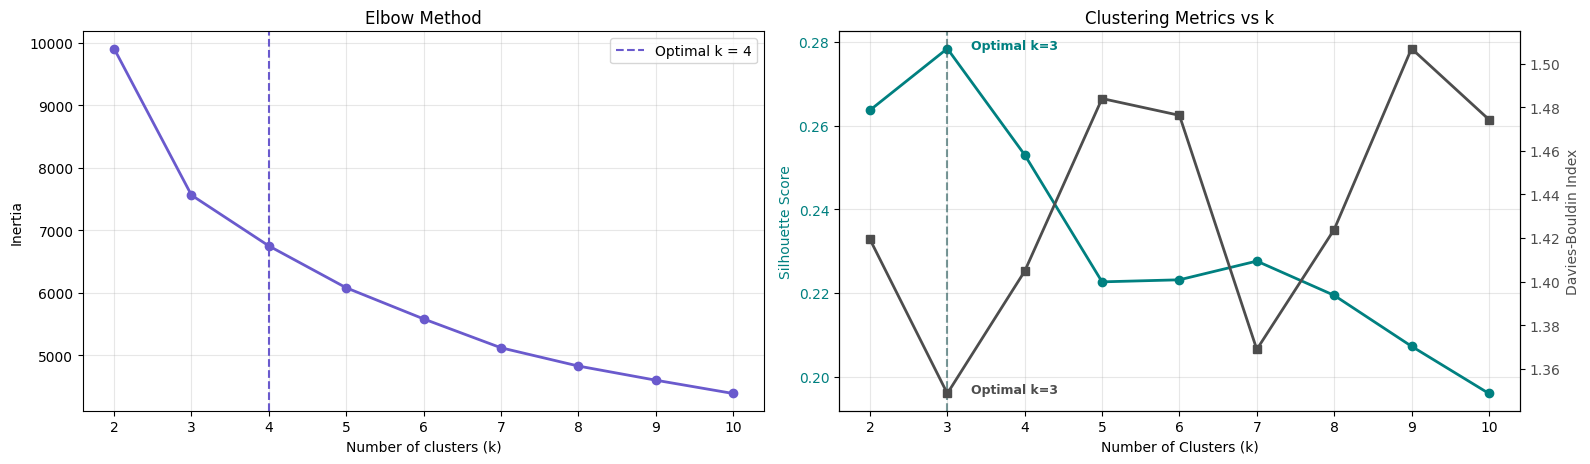

In [105]:
#Select best k
X, scaler, idx = preprocess_unsupervised(
    merged_df,
    feature_cols
)

k_results = evaluate_k_range(X, k_range=range(2, 11), method="kmeans")
print(k_results)

#Plot Evaluation for Kmeans
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_elbow(X, k_range=range(2, 11), ax=axes[0])
plot_all_clustering_metrics(k_results, ax=axes[1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

    k  silhouette       dbi
0   2    0.237565  1.647617
1   3    0.266794  1.352971
2   4    0.237190  1.397131
3   5    0.192811  1.549915
4   6    0.183200  1.567076
5   7    0.185843  1.607348
6   8    0.172542  1.579823
7   9    0.173570  1.470349
8  10    0.161744  1.554127


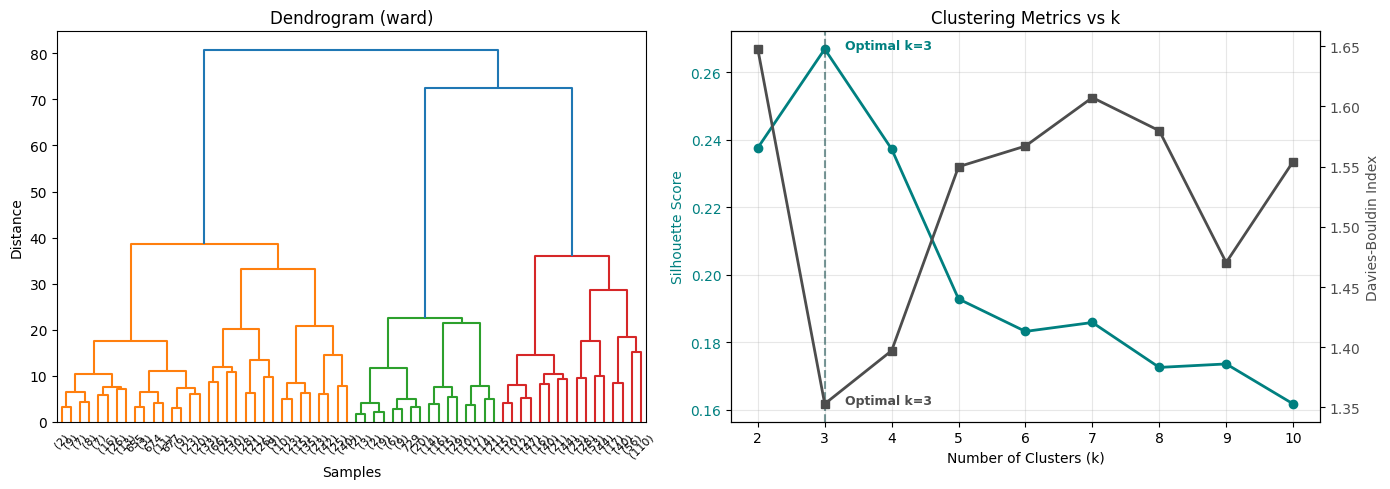

In [106]:
k_results = evaluate_k_range(X, k_range=range(2, 11), method="hierarchical")
print(k_results)

#Plot Evaluation for Hierarchical"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_dendrogram(X, ax=axes[0])
plot_all_clustering_metrics(k_results, ax=axes[1])

plt.tight_layout()
plt.show()

In [107]:
 # Use k-NN to fine tune parameter
def tune_dbscan(X, min_samples=5):
    """
    Plot k-NN distance curve to identify optimal eps for DBSCAN.
    Returns suggested eps at the elbow (90th percentile heuristic).
    """
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
    distances, _ = nbrs.kneighbors(X)
    knn_dists = np.sort(distances[:, -1])

    suggested_eps = np.percentile(knn_dists, 90)

    plt.figure(figsize=(9, 4))
    plt.plot(knn_dists, color="#4C72B0", linewidth=1.5)
    plt.axhline(suggested_eps, linestyle="--", color="red", linewidth=1.2,
                label=f"90th pct → eps={suggested_eps:.4f}")
    plt.title(f"k-NN Distance Plot (k={min_samples}) — find the elbow")
    plt.xlabel("Points (sorted)")
    plt.ylabel(f"{min_samples}-NN Distance")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Suggested eps : {suggested_eps:.4f}")
    print(f"min_samples   : {min_samples}")
    print("Adjust eps manually if the elbow falls at a different point on the curve.")

    return suggested_eps

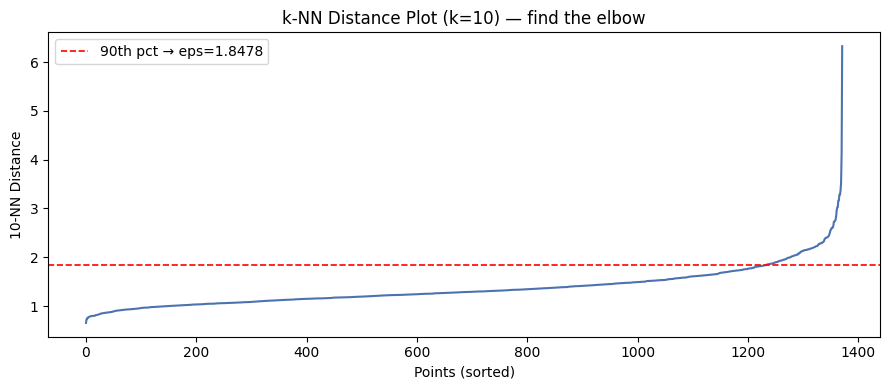

Suggested eps : 1.8478
min_samples   : 10
Adjust eps manually if the elbow falls at a different point on the curve.


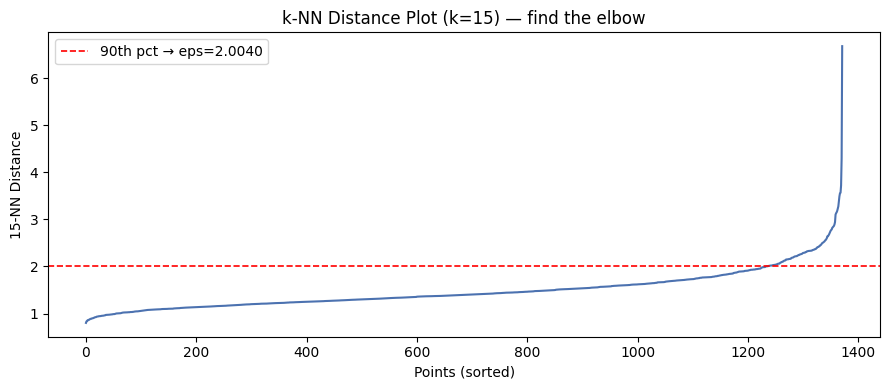

Suggested eps : 2.0040
min_samples   : 15
Adjust eps manually if the elbow falls at a different point on the curve.


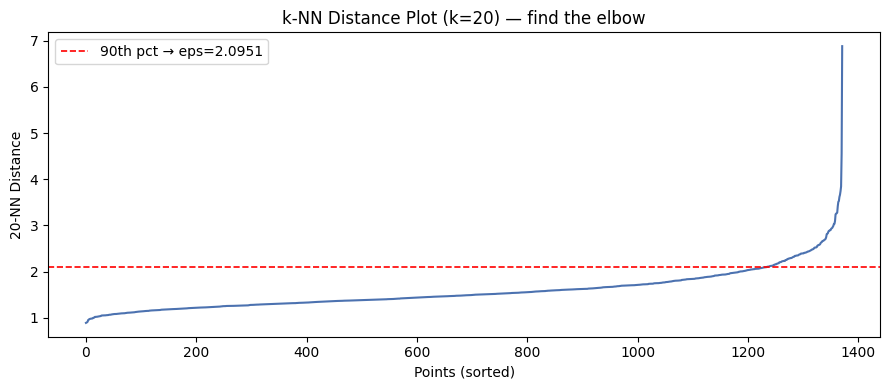

Suggested eps : 2.0951
min_samples   : 20
Adjust eps manually if the elbow falls at a different point on the curve.


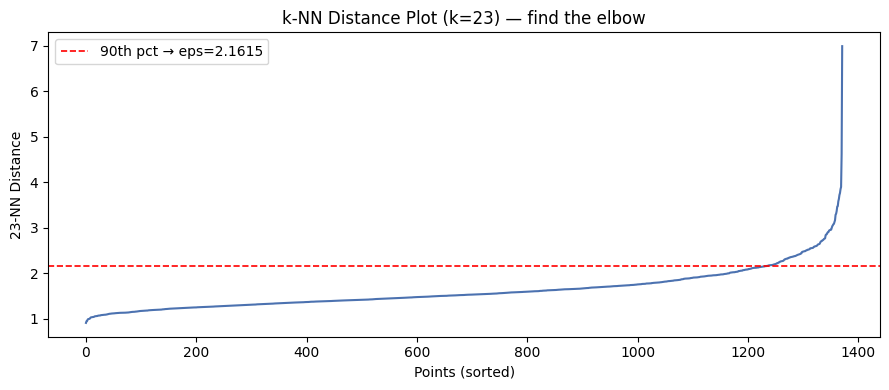

Suggested eps : 2.1615
min_samples   : 23
Adjust eps manually if the elbow falls at a different point on the curve.


In [108]:
# Test different min_samples values for DBSCAN
n_features = len(feature_cols)

min_samples_list = [
    n_features,
    int(round(1.5 * n_features)),
    2 * n_features,
    int(round(2.3 * n_features)),
]

results = {}

for min_samples in min_samples_list:
    # Estimate eps using k-distance method for each min_samples
    eps = tune_dbscan(X, min_samples=min_samples)

    labels, model = run_dbscan(X, eps=eps, min_samples=min_samples)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = np.mean(labels == -1)

    results[min_samples] = {
        "eps": eps,
        "labels": labels,
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
    }

### Run the pipeline and show the Clustering result using the optimized parameters

In [109]:
def run_unsupervised_pipeline(
    df,
    feature_cols,
    k=5,
    dbscan_params=None,
    feature_space="scaled",   # NEW PARAMETER
    mortality_col=None       # NEW
):
    """
    Runs full pipeline:
    preprocessing → PCA → clustering → evaluation → visualization

    feature_space:
        - "scaled": use standardized original features
        - "pca": use PCA-reduced features
    """

    # 1. preprocess
    X, scaler, idx = preprocess_unsupervised(df, feature_cols)

    # 2. PCA
    X_pca, pca = apply_pca(X, n_components=2)

    # 3. choose feature space
    if feature_space == "scaled":
        X_used = X
        #space_name = "Scaled Feature Space"
    elif feature_space == "pca":
        X_used = X_pca
        #space_name = "PCA Feature Space"
    else:
        raise ValueError("feature_space must be 'scaled' or 'pca'")

    # 4. models
    kmeans_labels, _ = run_kmeans(X_used, k=k)
    hier_labels, _ = run_hierarchical(X_used, k=k)

    if dbscan_params is None:
        dbscan_params = {"eps": 0.5, "min_samples": 5}

    db_labels, _ = run_dbscan(X_used, **dbscan_params)

    # remap if mortality column is provided
    if mortality_col is not None:
        mortality_series = df.loc[idx, mortality_col].values
        kmeans_labels = remap_labels_by_mortality(kmeans_labels, mortality_series)
        hier_labels   = remap_labels_by_mortality(hier_labels,   mortality_series)

    # 5. evaluation
    results = {
        "kmeans": evaluate_clustering(X_used, kmeans_labels),
        "hierarchical": evaluate_clustering(X_used, hier_labels),
        "dbscan": evaluate_clustering(X_used, db_labels)
    }

    # 6. visualization (always use PCA for plotting)# 6. visualization
    plot_pca_clusters_grid(
      X_pca,
      label_dict = {
          f"KMeans (k={k})"      : kmeans_labels,
          f"Hierarchical (k={k})": hier_labels,
          f"DBSCAN (ε={dbscan_params['eps']}, min_samples={dbscan_params['min_samples']})"      : db_labels,
      }
  )

    return {
        "X_used": X_used,
        "X_scaled": X,
        "X_pca": X_pca,
        "labels": {
            "kmeans": kmeans_labels,
            "hierarchical": hier_labels,
            "dbscan": db_labels
        },
        "pca": pca,
        "scaler": scaler,
        "evaluation": results,
        "feature_space": feature_space
    }

PCA: 2 components explain 63.2% of variance
Per component: ['42.2%', '21.0%']
Components needed for 95% variance: 7


/var/folders/1w/mk8xqpjx62b595g0t1k2k_200000gn/T/ipykernel_41468/3989297408.py:34: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_pca[mask, 0], X_pca[mask, 1],


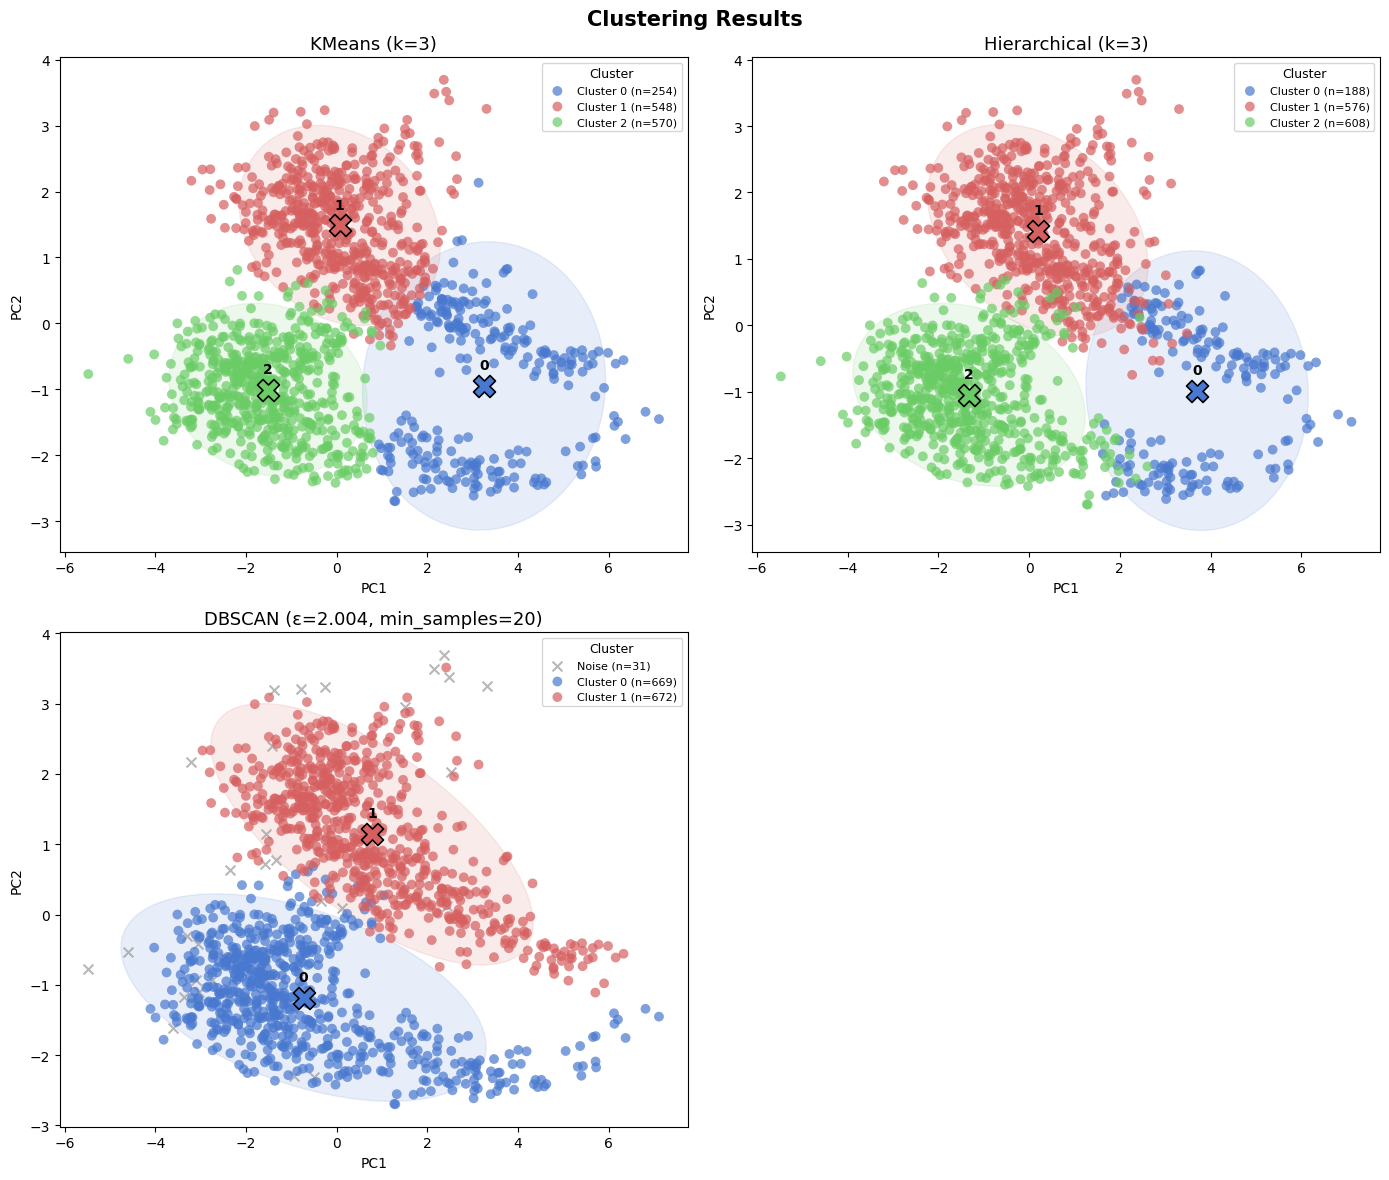

{'kmeans': {'silhouette': 0.27849002177670024, 'davies_bouldin': 1.3481627740424393, 'n_clusters': 3}, 'hierarchical': {'silhouette': 0.2667938814927373, 'davies_bouldin': 1.3529710152165588, 'n_clusters': 3}, 'dbscan': {'silhouette': 0.23591667428480817, 'davies_bouldin': 1.7698208820629266, 'n_clusters': 2}}


In [110]:
results = run_unsupervised_pipeline(
    merged_df,
    feature_cols=feature_cols,
    k=3,
    dbscan_params={"eps": 2.0040, "min_samples": 20},
    mortality_col="crude_rate_per_100k"
)

print(results["evaluation"])

In [111]:
X, scaler, idx = preprocess_unsupervised(merged_df, feature_cols)

df_clustered = merged_df.loc[idx].copy()

df_clustered["cluster_kmeans"] = results["labels"]["kmeans"]
df_clustered["cluster_hierarchical"] = results["labels"]["hierarchical"]
df_clustered["cluster_dbscan"] = results["labels"]["dbscan"]

In [112]:
#Dump dataframe to CSV
#base_path = '/content/drive/My Drive/MADS/SIADS 696 Milestone II/Group Project/Data/'
base_path = '../data/'
df_clustered.to_csv(f'{base_path}df_clustered.csv',index=False)

### Investigate DBSCAN Outliers

In [113]:
# Basic outlier counts 

print("DBSCAN label counts:")
print(df_clustered["cluster_dbscan"].value_counts().sort_index())

#Extract outliers (DBSCAN noise points = -1)

outliers_df = df_clustered[df_clustered["cluster_dbscan"] == -1]

print(f"\nNumber of outliers: {len(outliers_df)}")
print(f"Percent of dataset: {len(outliers_df) / len(df_clustered):.1%}")

# View demographic groups identified as outliers

display(outliers_df)

# Compare outliers vs overall population 

outlier_profile = pd.DataFrame({
    "Outlier Mean": outliers_df[feature_cols].mean(),
    "Overall Mean": df_clustered[feature_cols].mean()
})

outlier_profile["Difference"] = (
    outlier_profile["Outlier Mean"]
    - outlier_profile["Overall Mean"]
)

outlier_profile = outlier_profile.sort_values(
    "Difference",
    key=lambda x: abs(x),
    ascending=False
)

print("\nFeatures that most distinguish DBSCAN outliers:")
display(outlier_profile)

DBSCAN label counts:
cluster_dbscan
-1     31
 0    669
 1    672
Name: count, dtype: int64

Number of outliers: 31
Percent of dataset: 2.3%


,age,gender,year,deaths,crude_rate_per_100k,population,RIDAGEYR,RIAGENDR,SEQN,BMXWT,...,DMDEDUC2_9.0,DMDEDUC2_nan,SMQ020_1.0,SMQ020_2.0,SMQ020_7.0,SMQ020_9.0,SMQ020_nan,cluster_kmeans,cluster_hierarchical,cluster_dbscan
108,25.0,1,2003,2628.5,136.162206,1930304.5,25.0,1,17,93.135294,...,0.0,0.0,0.588235,0.411765,0.0,0.0,0.0,2,2,-1
129,27.0,1,2005,2806.0,145.624283,1926606.0,27.0,1,13,90.569231,...,0.0,0.0,0.538462,0.461538,0.0,0.0,0.0,2,2,-1
288,43.0,1,2003,7483.5,327.461571,2285726.5,43.0,1,20,87.660000,...,0.0,0.0,0.550000,0.450000,0.0,0.0,0.0,2,2,-1
357,50.0,1,2001,10368.0,555.862190,1865300.5,50.0,1,17,88.417647,...,0.0,0.0,0.823529,0.176471,0.0,0.0,0.0,2,2,-1
367,51.0,1,2001,10824.0,596.058516,1816226.0,51.0,1,23,89.386364,...,0.0,0.0,0.652174,0.347826,0.0,0.0,0.0,2,2,-1
375,51.0,1,2017,11427.0,545.705792,2095152.5,51.0,1,14,75.400000,...,0.0,0.0,0.571429,0.428571,0.0,0.0,0.0,2,2,-1
416,56.0,1,1999,12919.0,907.377791,1423773.0,56.0,1,17,82.420000,...,0.0,0.0,0.705882,0.294118,0.0,0.0,0.0,2,2,-1
417,56.0,1,2001,12242.5,887.743869,1379098.0,56.0,1,6,76.616667,...,0.0,0.0,0.666667,0.333333,0.0,0.0,0.0,2,2,-1
424,56.0,1,2015,18227.0,850.932705,2142003.5,56.0,1,6,85.866667,...,0.0,0.0,0.833333,0.166667,0.0,0.0,0.0,2,2,-1
437,58.0,1,2001,14033.0,1071.617522,1311226.5,58.0,1,14,90.471429,...,0.0,0.0,0.857143,0.142857,0.0,0.0,0.0,2,2,-1



Features that most distinguish DBSCAN outliers:


,Outlier Mean,Overall Mean,Difference
LBXTR,218.966630,131.458176,87.508454
age,64.193548,48.145773,16.047776
LBXGLU,121.287027,107.576009,13.711018
LBDLDL,119.858224,113.866475,5.991749
BPXDI1,65.395203,69.305357,-3.910154
BMXWAIST,99.104650,97.532796,1.571854
BMXWT,79.198208,79.972129,-0.773921
BMXBMI,28.299129,28.505361,-0.206232
LBDHDDSI,1.448511,1.395172,0.053339
gender,1.451613,1.500000,-0.048387


# Cluster Profiles — Descriptive Statistics & Mortality Rates

- **Cluster 0** — Young, low-risk population  
- **Cluster 1** — Older females, moderate cardiometabolic risk  
- **Cluster 2** — Older males, high cardiometabolic risk  

In [114]:
def create_cluster_profiles(
    df,
    feature_cols,
    cluster_col="cluster_kmeans",
    id_cols=None
):
    """
    Generate descriptive statistics for each cluster.

    """

    if id_cols is None:
        id_cols = []

    # Cluster size 
    cluster_size = (
        df.groupby(cluster_col)
        .size()
        .reset_index(name="count")
    )

    # Feature profiles
    cluster_summary = (
        df.groupby(cluster_col)[feature_cols]
        .mean()
        .round(3)
    )

    # Optional: attach cluster size 
    cluster_summary = cluster_summary.merge(
        cluster_size,
        left_index=True,
        right_on=cluster_col
    ).set_index(cluster_col)

    return cluster_summary, cluster_size

In [115]:
cluster_summary, cluster_size = create_cluster_profiles(
    df_clustered,
    feature_cols=feature_cols,
    cluster_col="cluster_hierarchical"
)

print(cluster_size)
display(cluster_summary)

   cluster_hierarchical  count
0                     0    188
1                     1    576
2                     2    608


,age,gender,BMXBMI,BMXWT,BMXWAIST,BPXDI1,LBXTR,LBDLDL,LBXGLU,LBDHDDSI,count
cluster_hierarchical,,,,,,,,,,,
0,18.904,1.585,25.188,69.369,85.145,61.167,85.750,91.162,94.660,1.403,188
1,53.505,2.000,29.617,76.380,97.783,68.964,130.293,118.103,107.098,1.528,576
2,52.110,1.000,28.478,86.654,101.126,72.145,146.696,116.873,112.023,1.267,608


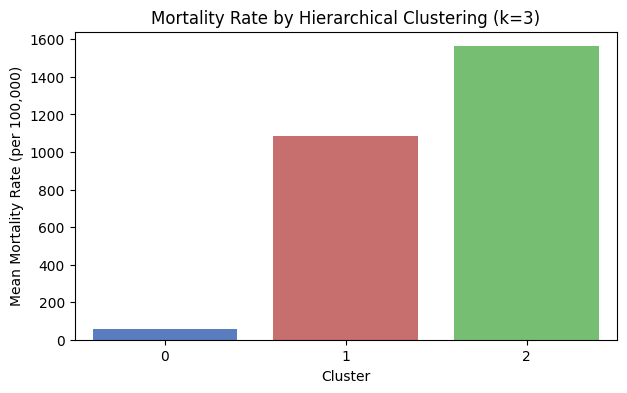

In [122]:
mortality_col = "crude_rate_per_100k"

palette = CLUSTER_COLORS  # FIXED

mortality_summary = (
    df_clustered
    .groupby("cluster_hierarchical")[mortality_col]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=mortality_summary,
    x="cluster_hierarchical",
    y="mean",
    palette=palette
)

plt.title("Mortality Rate by Hierarchical Clustering (k=3)")
plt.xlabel("Cluster")
plt.ylabel("Mean Mortality Rate (per 100,000)")
plt.show()

# Sensitivity Analysis

### 3 vs 4 Clusters

Moving from *k = 3* to *k = 4* does not substantially reorganize the clustering structure. Instead, the additional cluster emerges by splitting one existing cluster into two subgroups.

Two clusters remain stable across both solutions (n = 576 and n = 188). The third cluster (n = 608) is subdivided into two smaller groups (n = 451 and n = 157) under *k = 4*.

Importantly, the low-mortality cluster (n = 188) is fully preserved, while the newly formed subgroup (n = 157) represents an extreme high-mortality population.

Overall, this suggests that *k = 4* provides additional within-cluster granularity without altering the broader population structure. Therefore, *k = 3* is retained as the primary solution, with *k = 4* interpreted as a refinement rather than a fundamentally different clustering solution.

PCA: 2 components explain 63.2% of variance
Per component: ['42.2%', '21.0%']
Components needed for 95% variance: 7


/var/folders/1w/mk8xqpjx62b595g0t1k2k_200000gn/T/ipykernel_41468/3989297408.py:34: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_pca[mask, 0], X_pca[mask, 1],


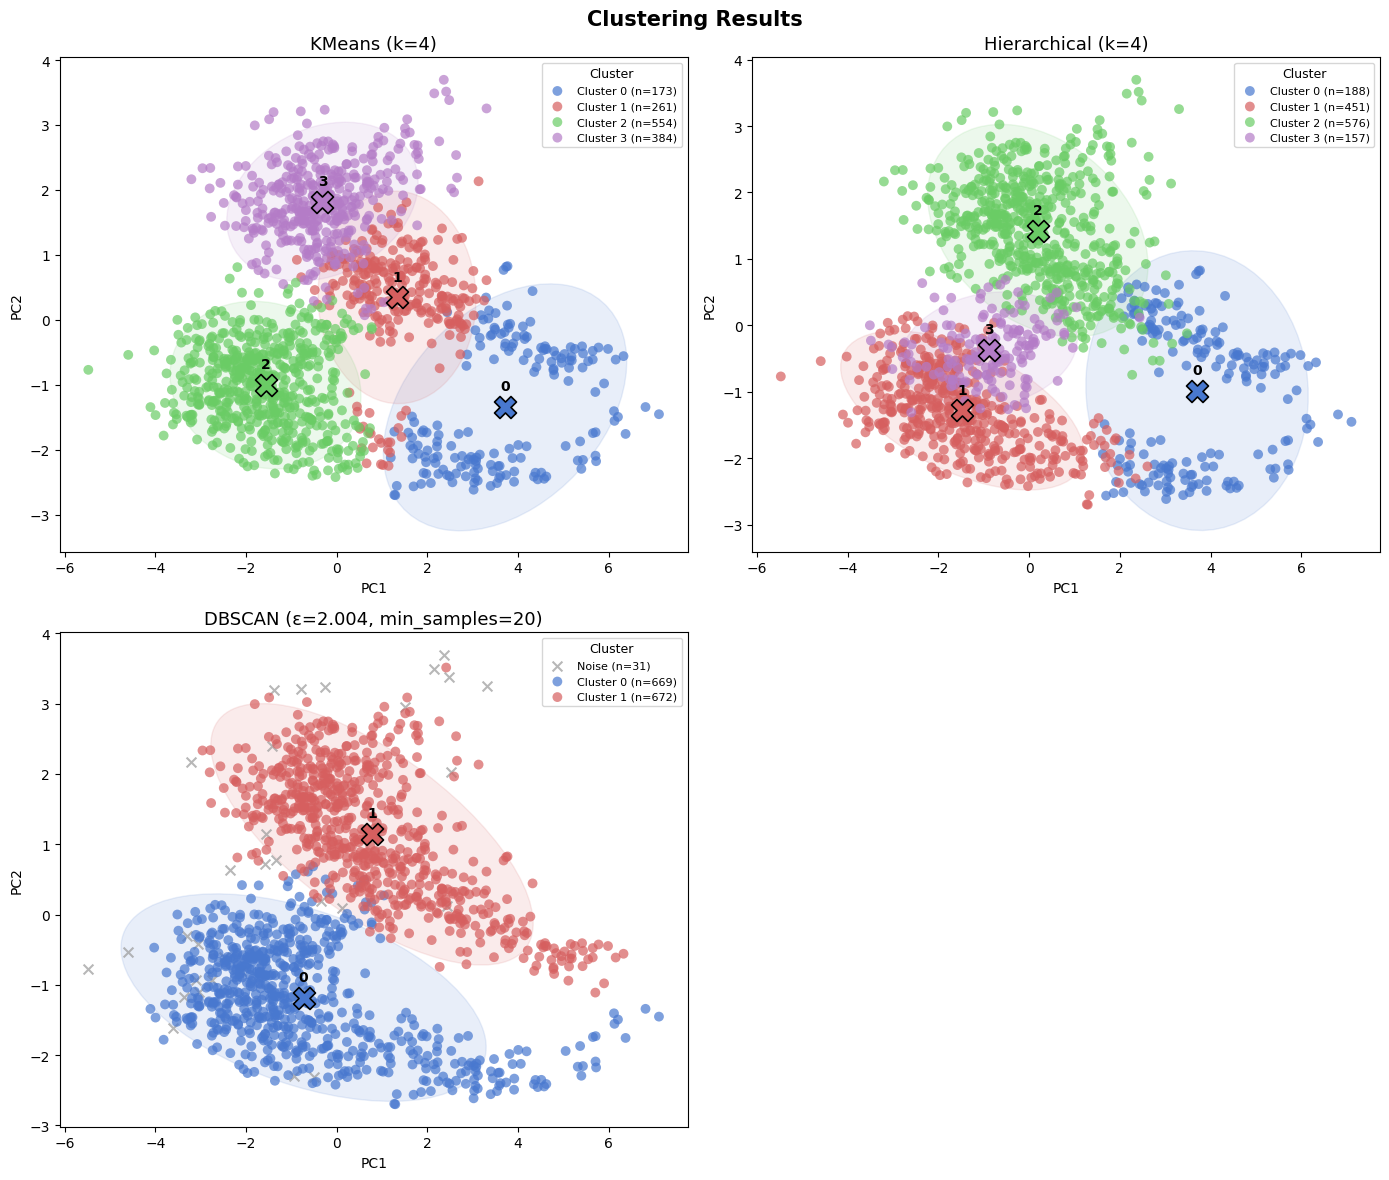

{'kmeans': {'silhouette': 0.23039531065588498, 'davies_bouldin': 1.4356430467788281, 'n_clusters': 4}, 'hierarchical': {'silhouette': 0.23718957594580023, 'davies_bouldin': 1.3971313119115383, 'n_clusters': 4}, 'dbscan': {'silhouette': 0.23591667428480817, 'davies_bouldin': 1.7698208820629266, 'n_clusters': 2}}


In [149]:
results = run_unsupervised_pipeline(
    merged_df,
    feature_cols=feature_cols,
    k=4,
    dbscan_params={"eps": 2.0040, "min_samples": 20},
    mortality_col="crude_rate_per_100k"
)

print(results["evaluation"])

In [152]:
X, scaler, idx = preprocess_unsupervised(merged_df, feature_cols)

df_clustered = merged_df.loc[idx].copy()

df_clustered["cluster_kmeans"] = results["labels"]["kmeans"]
df_clustered["cluster_hierarchical"] = results["labels"]["hierarchical"]
df_clustered["cluster_dbscan"] = results["labels"]["dbscan"]

In [153]:
cluster_summary, cluster_size = create_cluster_profiles(
    df_clustered,
    feature_cols=feature_cols,
    cluster_col="cluster_hierarchical"
)

print(cluster_size)
display(cluster_summary)

   cluster_hierarchical  count
0                     0    188
1                     1    451
2                     2    576
3                     3    157


,age,gender,BMXBMI,BMXWT,BMXWAIST,BPXDI1,LBXTR,LBDLDL,LBXGLU,LBDHDDSI,count
cluster_hierarchical,,,,,,,,,,,
0,18.904,1.585,25.188,69.369,85.145,61.167,85.750,91.162,94.660,1.403,188
1,44.827,1.000,28.664,88.050,100.235,74.032,153.849,121.086,109.682,1.248,451
2,53.505,2.000,29.617,76.380,97.783,68.964,130.293,118.103,107.098,1.528,576
3,73.032,1.000,27.943,82.644,103.687,66.724,126.147,104.772,118.746,1.322,157


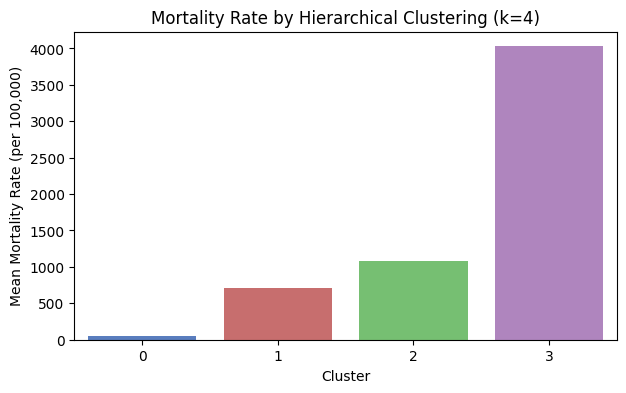

In [154]:
mortality_col = "crude_rate_per_100k"

palette = CLUSTER_COLORS  # FIXED

mortality_summary = (
    df_clustered
    .groupby("cluster_hierarchical")[mortality_col]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

plt.figure(figsize=(7, 4))

sns.barplot(
    data=mortality_summary,
    x="cluster_hierarchical",
    y="mean",
    palette=palette
)

plt.title("Mortality Rate by Hierarchical Clustering (k=4)")
plt.xlabel("Cluster")
plt.ylabel("Mean Mortality Rate (per 100,000)")
plt.show()

### Bootstrap Stability

Hierarchical clustering shows perfect stability under bootstrap resampling, indicating highly consistent cluster assignments across subsamples. KMeans also demonstrates strong stability (mean ARI ≈ 0.97), but with slightly higher variability.

Overall, both methods produce robust clustering structures at *k = 3*, with hierarchical clustering exhibiting marginally greater stability in this dataset.

In [162]:
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

def bootstrap_stability(X, k, n_boot=50, sample_frac=0.8, seed=42):
    rng = np.random.RandomState(seed)
    scores = []

    km_ref = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(X)

    for _ in range(n_boot):
        idx = rng.choice(len(X), size=int(len(X) * sample_frac), replace=True)
        X_boot = X[idx]

        km_boot = KMeans(n_clusters=k, random_state=rng.randint(1e6), n_init=10).fit(X_boot)

        ref_sub = km_ref.predict(X_boot)

        scores.append(adjusted_rand_score(ref_sub, km_boot.labels_))

    return np.mean(scores), np.std(scores)

In [163]:
def bootstrap_stability_hierarchical(
    X,
    k,
    n_boot=50,
    sample_frac=0.8,
    method="ward",
    seed=42,
):
    """
    Estimate clustering stability for hierarchical clustering using bootstrap + ARI.

    Parameters
    ----------
    X : array-like
        Feature matrix.
    k : int
        Number of clusters.
    n_boot : int
        Number of bootstrap samples.
    sample_frac : float
        Fraction of samples per bootstrap.
    method : str
        Linkage method for hierarchical clustering.

    Returns
    -------
    mean_ari : float
        Average stability score.
    std_ari : float
        Standard deviation of stability scores.
    """

    rng = np.random.RandomState(seed)
    scores = []

    n_samples = len(X)

    for _ in range(n_boot):
        idx = rng.choice(n_samples, size=int(n_samples * sample_frac), replace=True)
        X_boot = X[idx]

        # Hierarchical clustering on bootstrap sample
        Z_boot = linkage(X_boot, method=method)
        labels_boot = fcluster(Z_boot, k, criterion="maxclust")

        # Reference clustering on same bootstrap sample (fixed model for comparison)
        Z_ref = linkage(X_boot, method=method)
        labels_ref = fcluster(Z_ref, k, criterion="maxclust")

        scores.append(adjusted_rand_score(labels_ref, labels_boot))

    return np.mean(scores), np.std(scores)

In [164]:
# Get data
X, scaler, idx = preprocess_unsupervised(merged_df, feature_cols)

# Run stability test
mean_ari, std_ari = bootstrap_stability(X, k=3)
mean_ari_h, std_ari_h = bootstrap_stability_hierarchical(X, k=3)

# Print result
print(f"KMeans Stability (k=3): {mean_ari:.3f} ± {std_ari:.3f}")
print(f"Hierarchical Stability (k=3): {mean_ari_h:.3f} ± {std_ari_h:.3f}")

KMeans Stability (k=3): 0.972 ± 0.027
Hierarchical Stability (k=3): 1.000 ± 0.000
